## 01 — Dataset + QLoRA fine-tuning (Colab)

This notebook:

- Generates a **260-example** synthetic dataset (train/valid/test) as JSONL
- Fine-tunes a **<1B** model with **QLoRA** (Unsloth)
- Uses **early stopping** on validation loss
- Saves LoRA adapters and training logs

> **Colab free tier**: target **< 2 hours GPU** on **T4** (install + download model + train + eval in notebook 02). Defaults: **2 epochs**, `max_seq_length=1024`, QLoRA r=16.


In [1]:
# Google Drive is **optional**. Do not mount here — it breaks automated `nbconvert` runs.
# After training, use the last cell to copy `tatweer_challenge/` to Drive if you want persistence.
print("Ready. Enable GPU: Runtime → Change runtime type → T4 GPU → Restart session, then Run all.")

Ready. Enable GPU: Runtime → Change runtime type → T4 GPU → Restart session, then Run all.


In [2]:
# Colab setup (GPU required for Unsloth)
import os, sys
os.environ["WANDB_DISABLED"] = "true"

import torch
print("torch:", torch.__version__)
print("cuda available:", torch.cuda.is_available())

if not torch.cuda.is_available():
    raise SystemExit(
        "No GPU detected. In Colab: Runtime → Change runtime type → Hardware accelerator: GPU. "
        "Then Runtime → Restart session, and re-run this cell."
    )

# Only if torch is CPU-only, uncomment and run once (avoid downgrading a working CUDA build e.g. cu128):
# !pip -q install -U torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121

# Plain `unsloth` + no protobuf pin — unsloth[colab] + protobuf<6 often fails resolver (see pip error).
!pip -q install -U unsloth transformers datasets accelerate peft trl bitsandbytes evaluate sacrebleu rouge-score scikit-learn matplotlib seaborn "pandas<3"

torch: 2.10.0+cu128
cuda available: True
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.8/55.8 kB 3.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 kB 2.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.2/91.2 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.6/62.6 MB 14.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 132.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 506.8/506.8 kB 44.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 423.1/423.1 kB 37.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 12.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 8.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.8/100.8 kB 11.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 127.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [3]:
# Repo bootstrap — works on **Colab** (`/content/tatweer_challenge`) and **local** Jupyter (this folder)
import os
import subprocess
from pathlib import Path
from typing import Optional

def _find_repo_dir() -> Optional[Path]:
    p = Path.cwd().resolve()
    for _ in range(16):
        if (p / "data" / "processed").is_dir() and (p / "scripts" / "generate_dataset.py").is_file():
            return p
        p = p.parent
    c = Path("/content/tatweer_challenge")
    return c if c.is_dir() else None

repo_dir = _find_repo_dir()
if repo_dir is None and Path("/content").is_dir():
    subprocess.run(
        ["git", "clone", "-q", "https://github.com/shamemdeen/ttw-challenge.git", "/content/tatweer_challenge"],
        check=False,
    )
    repo_dir = _find_repo_dir()
if repo_dir is None:
    raise FileNotFoundError(
        "Could not find tatweer_challenge. Open this notebook from .../tatweer_challenge/notebooks/ "
        "or clone the repo to /content/tatweer_challenge (Colab)."
    )
os.chdir(str(repo_dir / "notebooks"))
print("repo_dir:", repo_dir)
print("cwd:", os.getcwd())

repo_dir: /content/tatweer_challenge
cwd: /content/tatweer_challenge/notebooks


In [4]:
# Generate dataset (writes JSONL to ../data/processed)
import json, random
from pathlib import Path

root = Path("..").resolve()  # your-name-challenge/
out_dir = root / "data" / "processed"
out_dir.mkdir(parents=True, exist_ok=True)


def ps(code: str) -> str:
    return f"```powershell\n{code.strip()}\n```"


def join_steps(steps):
    return "\n".join([f"{i+1}. {s}" for i, s in enumerate(steps)])


def build_examples(seed: int = 3407):
    rng = random.Random(seed)
    examples = []

    # A compact in-notebook version of the generator (kept deterministic)
    examples.append({
        "id": "network_dns_cache",
        "category": "network",
        "expects_code": True,
        "difficulty": 1,
        "instruction": "My Windows PC can open some websites but others fail with DNS errors. Give me PowerShell steps to diagnose and fix DNS issues safely.",
        "response": "\n".join([
            "Start with read-only checks, then reset DNS client state if needed.",
            "",
            join_steps([
                "Check current DNS server configuration and adapter status.",
                "Test name resolution against your configured DNS and a public resolver.",
                "Flush the DNS client cache (safe) and retry.",
                "If it still fails, reset the DNS client service and renew the IP lease.",
            ]),
            "",
            ps("""
Get-NetAdapter | Sort-Object Status -Descending | Format-Table -Auto Name, Status, LinkSpeed
Get-DnsClientServerAddress -AddressFamily IPv4 | Format-Table -Auto InterfaceAlias, ServerAddresses

Resolve-DnsName -Name "www.microsoft.com" -ErrorAction SilentlyContinue
Resolve-DnsName -Name "www.microsoft.com" -Server 1.1.1.1 -ErrorAction SilentlyContinue

Clear-DnsClientCache

Restart-Service -Name Dnscache -Force
ipconfig /renew
"""),
            "",
            "If `Resolve-DnsName` works only with `-Server 1.1.1.1`, your local DNS server is likely the problem (router/ISP/enterprise DNS).",
        ])
    })

    proxy_hosts = ["login.company.tld", "intranet.local", "api.vendor.tld"]
    for i, h in enumerate(proxy_hosts):
        examples.append({
            "id": f"network_proxy_{i}",
            "category": "network",
            "expects_code": True,
            "difficulty": 2,
            "instruction": f"Ping is blocked on my network. I can’t reach {h}. How do I troubleshoot connectivity using PowerShell without ICMP?",
            "response": "\n".join([
                "If ICMP is blocked, validate DNS, route, and TCP connectivity instead of ping.",
                "",
                ps(f"""
$hostName = "{h}"
Resolve-DnsName -Name $hostName -ErrorAction SilentlyContinue

Test-NetConnection -ComputerName $hostName -Port 443 -InformationLevel Detailed
Test-NetConnection -ComputerName $hostName -Port 80  -InformationLevel Detailed

tracert -d $hostName
"""),
                "",
                "If DNS fails, fix name resolution first. If DNS works but TCP fails, check firewall/proxy requirements and local outbound rules.",
            ])
        })

    services = [("Spooler", "Print Spooler"), ("wuauserv", "Windows Update"), ("WinDefend", "Microsoft Defender Antivirus Service")]
    for svc, desc in services:
        examples.append({
            "id": f"svc_restart_{svc.lower()}",
            "category": "services",
            "expects_code": True,
            "difficulty": 1,
            "instruction": f"{desc} seems stuck. How do I check its status and restart it in PowerShell?",
            "response": "\n".join([
                "Check status and recent dependent services first, then restart. If you see access denied, run PowerShell as Administrator.",
                "",
                ps(f"""
$name = "{svc}"
Get-Service -Name $name | Format-List *

(Get-Service -Name $name).DependentServices | Format-Table -Auto Name, Status

Restart-Service -Name $name -Force
Get-Service -Name $name
"""),
            ])
        })

    # Pad to 260 with templated “explain error” items
    error_templates = [
        ("network", "Name resolution failure", "Resolve-DnsName"),
        ("services", "Service cannot be started", "Get-WinEvent"),
        ("permissions", "Access is denied", "Get-Acl"),
        ("disk", "The disk is write-protected", "Get-Volume"),
        ("processes", "Process is not responding", "Get-Process"),
    ]

    idx = 0
    while len(examples) < 260:
        cat, err, cmd = error_templates[idx % len(error_templates)]
        idx += 1
        examples.append({
            "id": f"err_explain_{idx:03d}",
            "category": cat,
            "expects_code": True,
            "difficulty": 2 if (idx % 3) else 3,
            "instruction": f"I'm seeing this error in PowerShell: '{err}'. Explain likely causes and give a short diagnostic checklist with commands.",
            "response": "\n".join([
                "That error usually points to a few common root causes. Start with quick diagnostics before changing configuration.",
                "",
                join_steps([
                    "Confirm the exact command and parameters that triggered the error.",
                    "Check whether you have the required privileges (standard user vs admin).",
                    "Collect the most relevant state using built-in commands.",
                    "If the issue is reproducible, capture an event log snippet around the failure time.",
                ]),
                "",
                ps(f"""
whoami
{cmd} | Out-String | Select-Object -First 1
"""),
                "",
                "If you paste the exact command and the full error (including any category info), the next steps can be narrowed down safely.",
            ])
        })

    rng.shuffle(examples)
    return examples


examples = build_examples(seed=3407)
assert len(examples) >= 260

train, valid, test = examples[:220], examples[220:240], examples[240:260]

for name, split in [("train", train), ("valid", valid), ("test", test)]:
    path = out_dir / f"{name}.jsonl"
    with path.open("w", encoding="utf-8") as f:
        for ex in split:
            f.write(json.dumps(ex, ensure_ascii=False) + "\n")

print("Wrote:")
for name in ["train", "valid", "test"]:
    print(name, sum(1 for _ in (out_dir / f"{name}.jsonl").open("r", encoding="utf-8")))

Wrote:
train 220
valid 20
test 20


In [5]:
# Load dataset
from datasets import load_dataset
from pathlib import Path

root = Path("..").resolve()
data_dir = root / "data" / "processed"

raw = load_dataset(
    "json",
    data_files={
        "train": str(data_dir / "train.jsonl"),
        "validation": str(data_dir / "valid.jsonl"),
        "test": str(data_dir / "test.jsonl"),
    },
)
raw

Generating train split: 0 examples [00:00, ? examples/s]

Generating validation split: 0 examples [00:00, ? examples/s]

Generating test split: 0 examples [00:00, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['id', 'category', 'expects_code', 'difficulty', 'instruction', 'response'],
        num_rows: 220
    })
    validation: Dataset({
        features: ['id', 'category', 'expects_code', 'difficulty', 'instruction', 'response'],
        num_rows: 20
    })
    test: Dataset({
        features: ['id', 'category', 'expects_code', 'difficulty', 'instruction', 'response'],
        num_rows: 20
    })
})

In [6]:
# Convert to SFT text format (instruction-response)

def to_sft_text(ex):
    return {
        "text": "\n".join([
            "### Instruction:",
            ex["instruction"].strip(),
            "",
            "### Response:",
            ex["response"].strip(),
        ])
    }

train_ds = raw["train"].map(to_sft_text, remove_columns=raw["train"].column_names)
val_ds = raw["validation"].map(to_sft_text, remove_columns=raw["validation"].column_names)

train_ds[0]["text"][:600]

Map:   0%|          | 0/220 [00:00<?, ? examples/s]

Map:   0%|          | 0/20 [00:00<?, ? examples/s]

"### Instruction:\nI'm seeing this error in PowerShell: 'Access is denied'. Explain likely causes and give a short diagnostic checklist with commands.\n\n### Response:\nThat error usually points to a few common root causes. Start with quick diagnostics before changing configuration.\n\n1. Confirm the exact command and parameters that triggered the error.\n2. Check whether you have the required privileges (standard user vs admin).\n3. Collect the most relevant state using built-in commands.\n4. If the issue is reproducible, capture an event log snippet around the failure time.\n\n```powershell\nwhoami\nGet-A"

In [7]:
# QLoRA fine-tuning (Unsloth) — tuned for Colab T4 + <2h GPU budget
# Self-heal: install into *this* kernel if you skipped the pip cell or restarted without deps.
def _ensure_unsloth():
    try:
        import unsloth  # noqa: F401
        return
    except ModuleNotFoundError:
        pass
    from IPython import get_ipython
    ip = get_ipython()
    pip_line = (
        'install -q -U unsloth transformers datasets accelerate peft trl bitsandbytes '
        'evaluate sacrebleu rouge-score scikit-learn matplotlib seaborn "pandas<3"'
    )
    if ip is not None:
        ip.run_line_magic("pip", pip_line)
    else:
        import subprocess
        import sys
        subprocess.check_call(
            [sys.executable, "-m", "pip", "install", "-q", "-U", "--break-system-packages",
             "unsloth", "transformers", "datasets", "accelerate", "peft", "trl", "bitsandbytes",
             "evaluate", "sacrebleu", "rouge-score", "scikit-learn", "matplotlib", "seaborn", "pandas<3"],
        )

_ensure_unsloth()

import math
import torch
from pathlib import Path
from unsloth import FastLanguageModel

model_name = "Qwen/Qwen2.5-0.5B-Instruct"  # < 1B params
max_seq_length = 1024  # enough for this dataset; faster tokenization + train on T4

model, tokenizer = FastLanguageModel.from_pretrained(
    model_name=model_name,
    max_seq_length=max_seq_length,
    dtype=None,
    load_in_4bit=True,
)

# LoRA config (justify in your report)
# - r=16: enough capacity for domain adaptation on small dataset
# - alpha=32: stable scaling
# - dropout=0.05: helps prevent overfitting on 220 train samples
model = FastLanguageModel.get_peft_model(
    model,
    r=16,
    target_modules=[
        "q_proj", "k_proj", "v_proj", "o_proj",
        "gate_proj", "up_proj", "down_proj",
    ],
    lora_alpha=32,
    lora_dropout=0.05,
    bias="none",
    use_gradient_checkpointing="unsloth",
    random_state=3407,
)

from trl import SFTTrainer
from transformers import TrainingArguments, EarlyStoppingCallback

out_root = Path("..").resolve() / "outputs"
out_root.mkdir(parents=True, exist_ok=True)

# ~14 optimizer steps/epoch (220 / (2*8)); 2 epochs ≈ 28 steps — fits T4 quickly
per_device_train_batch_size = 2
gradient_accumulation_steps = 8
num_train_epochs = 2
steps_per_epoch = math.ceil(len(train_ds) / (per_device_train_batch_size * gradient_accumulation_steps))
total_steps = steps_per_epoch * num_train_epochs
warmup_steps = max(1, int(total_steps * 0.03))
eval_steps = steps_per_epoch  # once per epoch

args = TrainingArguments(
    output_dir=str(out_root / "checkpoints"),
    per_device_train_batch_size=per_device_train_batch_size,
    per_device_eval_batch_size=2,
    gradient_accumulation_steps=gradient_accumulation_steps,  # effective batch = 16
    learning_rate=2e-4,
    num_train_epochs=num_train_epochs,
    warmup_steps=warmup_steps,
    lr_scheduler_type="cosine",
    logging_steps=max(1, steps_per_epoch // 2),
    eval_strategy="steps",
    eval_steps=eval_steps,
    save_strategy="steps",
    save_steps=eval_steps,
    save_total_limit=3,
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,
    fp16=not torch.cuda.is_bf16_supported(),
    bf16=torch.cuda.is_bf16_supported(),
    report_to=[],
    seed=3407,
)

trainer = SFTTrainer(
    model=model,
    tokenizer=tokenizer,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    dataset_text_field="text",
    max_seq_length=max_seq_length,
    args=args,
)

trainer.add_callback(EarlyStoppingCallback(early_stopping_patience=2))

train_result = trainer.train()
train_result

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!
==((====))==  Unsloth 2026.4.4: Fast Qwen2 patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


model.safetensors:   0%|          | 0.00/538M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/270 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

...

Unsloth: Tokenizing ["text"] (num_proc=6):   0%|          | 0/20 [00:00<?, ? examples/s]

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None}.
==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 220 | Num Epochs = 2 | Total steps = 28
O^O/ \_/ \    Batch size per device = 2 | Gradient accumulation steps = 8
\        /    Data Parallel GPUs = 1 | Total batch size (2 x 8 x 1) = 16
 "-____-"     Trainable parameters = 8,798,208 of 502,830,976 (1.75% trained)
`use_return_dict` is deprecated! Use `return_dict` instead!


Step,Training Loss,Validation Loss
14,0.272419,0.027561
28,0.063532,0.013480


/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:281: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:172: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API 

TrainOutput(global_step=28, training_loss=0.610249902520861, metrics={'train_runtime': 93.1036, 'train_samples_per_second': 4.726, 'train_steps_per_second': 0.301, 'total_flos': 156701071818240.0, 'train_loss': 0.610249902520861, 'epoch': 2.0})

Saved: /content/tatweer_challenge/outputs/loss_curve.png
Saved: /content/tatweer_challenge/outputs/trainer_log_history.json

LoRA / tokenizer directory: /content/tatweer_challenge/outputs/lora_adapters
  README.md: 5.1 KB
  adapter_config.json: 1.2 KB
  adapter_model.safetensors: 33.60 MB
  chat_template.jinja: 2.4 KB
  tokenizer.json: 10.89 MB
  tokenizer_config.json: 0.4 KB

OK: adapter weights saved — copy this folder to disk / use in 02_evaluation.ipynb.
Saved: /content/tatweer_challenge/outputs/training_summary.json


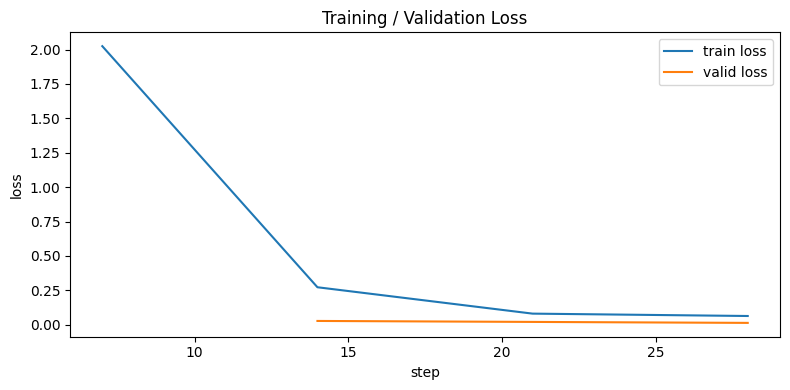

In [8]:
# Save fine-tuned weights + tokenizer + loss artifacts (Challenge 2 deliverables)
# ---------------------------------------------------------------------------
# After this cell you should have:
#   outputs/lora_adapters/adapter_config.json
#   outputs/lora_adapters/adapter_model.safetensors   ← LoRA weights (required for 02)
#   outputs/lora_adapters/tokenizer*.json, chat_template.jinja, ...
#   outputs/loss_curve.png
#   outputs/trainer_log_history.json
#   outputs/training_summary.json  (final train metrics + best checkpoint path)
# Training checkpoints (from TrainingArguments) live under: outputs/checkpoints/
# ---------------------------------------------------------------------------
import json
import matplotlib.pyplot as plt
from datetime import datetime, timezone
from pathlib import Path

out_base = Path("..").resolve() / "outputs"
save_dir = out_base / "lora_adapters"
save_dir.mkdir(parents=True, exist_ok=True)

# Fine-tuned = LoRA adapters on the frozen 4-bit base (PEFT save_pretrained)
trainer.model.save_pretrained(str(save_dir))
tokenizer.save_pretrained(str(save_dir))

# Extract loss curves
history = trainer.state.log_history
train_steps, train_loss = [], []
eval_steps, eval_loss = [], []

for row in history:
    if "loss" in row and "step" in row:
        train_steps.append(row["step"])
        train_loss.append(row["loss"])
    if "eval_loss" in row and "step" in row:
        eval_steps.append(row["step"])
        eval_loss.append(row["eval_loss"])

plt.figure(figsize=(8,4))
if train_steps:
    plt.plot(train_steps, train_loss, label="train loss")
if eval_steps:
    plt.plot(eval_steps, eval_loss, label="valid loss")
plt.xlabel("step")
plt.ylabel("loss")
plt.title("Training / Validation Loss")
plt.legend()
plt.tight_layout()

plot_path = out_base / "loss_curve.png"
plt.savefig(plot_path, dpi=160)
print("Saved:", plot_path)

log_path = out_base / "trainer_log_history.json"
with open(log_path, "w", encoding="utf-8") as f:
    json.dump(history, f, ensure_ascii=False, indent=2)
print("Saved:", log_path)

print("\nLoRA / tokenizer directory:", save_dir)
for p in sorted(save_dir.iterdir()):
    if p.is_file():
        sz = p.stat().st_size
        sz_s = f"{sz / 1_048_576:.2f} MB" if sz >= 1_048_576 else f"{sz / 1024:.1f} KB"
        print(f"  {p.name}: {sz_s}")
weights = save_dir / "adapter_model.safetensors"
if not weights.is_file() or weights.stat().st_size == 0:
    print("\nWARNING: adapter_model.safetensors missing or empty — notebook 02 cannot load fine-tuned model.")
else:
    print("\nOK: adapter weights saved — copy this folder to disk / use in 02_evaluation.ipynb.")

_ta = trainer.args
training_summary = {
    "challenge": "Challenge 2",
    "saved_at_utc": datetime.now(timezone.utc).isoformat(),
    "base_model_name": model_name,
    "train_result_metrics": dict(getattr(train_result, "metrics", {}) or {}),
    "trainer_state": {
        "global_step": trainer.state.global_step,
        "best_model_checkpoint": getattr(trainer.state, "best_model_checkpoint", None),
        "best_metric": getattr(trainer.state, "best_metric", None),
    },
    "training_args": {
        "output_dir": str(_ta.output_dir),
        "num_train_epochs": _ta.num_train_epochs,
        "learning_rate": _ta.learning_rate,
        "per_device_train_batch_size": _ta.per_device_train_batch_size,
        "gradient_accumulation_steps": _ta.gradient_accumulation_steps,
        "warmup_steps": _ta.warmup_steps,
        "lr_scheduler_type": _ta.lr_scheduler_type,
        "eval_strategy": str(_ta.eval_strategy),
        "save_strategy": str(_ta.save_strategy),
        "load_best_model_at_end": _ta.load_best_model_at_end,
        "metric_for_best_model": _ta.metric_for_best_model,
        "fp16": _ta.fp16,
        "bf16": _ta.bf16,
        "seed": _ta.seed,
    },
}
sum_path = out_base / "training_summary.json"
with open(sum_path, "w", encoding="utf-8") as f:
    json.dump(training_summary, f, ensure_ascii=False, indent=2)
print("Saved:", sum_path)

In [9]:
# OPTIONAL: copy project (data/processed + outputs/) to Google Drive for safekeeping
SAVE_TO_DRIVE = False
DRIVE_DEST = "/content/drive/MyDrive/tatweer_challenge_submission"

if SAVE_TO_DRIVE:
    from google.colab import drive
    drive.mount("/content/drive")
    import shutil
    from pathlib import Path
    src = Path("..").resolve()
    shutil.copytree(src, DRIVE_DEST, dirs_exist_ok=True)
    print("Copied to:", DRIVE_DEST)
else:
    print("Set SAVE_TO_DRIVE=True, run again, approve Drive auth — or download /content/tatweer_challenge from Files menu.")

Set SAVE_TO_DRIVE=True, run again, approve Drive auth — or download /content/tatweer_challenge from Files menu.


In [10]:
# GPU sanity check — run this in the SAME kernel you use for training
import sys

import torch

print("Python exe:", sys.executable)
print("torch:", torch.__version__)
print("cuda available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("device 0:", torch.cuda.get_device_name(0))
    print("device count:", torch.cuda.device_count())
else:
    print(
        "\nNo CUDA in this kernel — Unsloth/QLoRA needs a GPU in this session.\n"
        "If you expect Colab T4:\n"
        "  • Runtime → Change runtime type → GPU (T4) → Save, then Runtime → Restart session.\n"
        "  • In VS Code/Cursor: pick the Colab/Jupyter kernel that runs on Colab, not local Windows Python.\n"
        "  • A CPU-only torch build (often shows '+cpu' in torch.__version__) cannot see a GPU.\n"
    )


Python exe: /usr/bin/python3
torch: 2.10.0+cu128
cuda available: True
device 0: Tesla T4
device count: 1


In [11]:
import torch
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0) if torch.cuda.is_available() else "no gpu")

True
Tesla T4
